<a href="https://colab.research.google.com/github/ThienPhu2708/2001230673_PhungDuongThienPhu_THDeepLearning_Buoi04/blob/main/CNN_BT03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

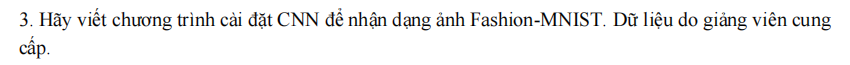

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile, os

zip_path = '/content/drive/MyDrive/Fashion_MINST.zip'

if not os.path.exists('/content/fashion'):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('/content/fashion')
    print("Giải nén xong!")
else:
    print("Đã tồn tại, bỏ qua.")

# Kiểm tra cấu trúc
for root, dirs, files in os.walk('/content/fashion'):
    level = root.replace('/content/fashion', '').count(os.sep)
    print('  ' * level + os.path.basename(root) + f'/ ({len(files)} files)')

Giải nén xong!
fashion/ (3 files)


In [ ]:
import pandas as pd

num_classes = 10
input_shape = (28, 28, 1)  # grayscale như MNIST

# Load the datasets
train_df = pd.read_csv('/content/fashion/fashion-mnist_train.csv')
test_df = pd.read_csv('/content/fashion/fashion-mnist_test.csv')

# Separate features (X) and labels (y)
X_train = train_df.drop('label', axis=1).values
y_train = train_df['label'].values
X_test = test_df.drop('label', axis=1).values
y_test = test_df['label'].values

# Normalize & reshape
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)
X_test  = X_test.reshape(X_test.shape[0],   28, 28, 1)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test  = keras.utils.to_categorical(y_test,  num_classes)

X_train: (60000, 28, 28, 1)
X_test:  (10000, 28, 28, 1)


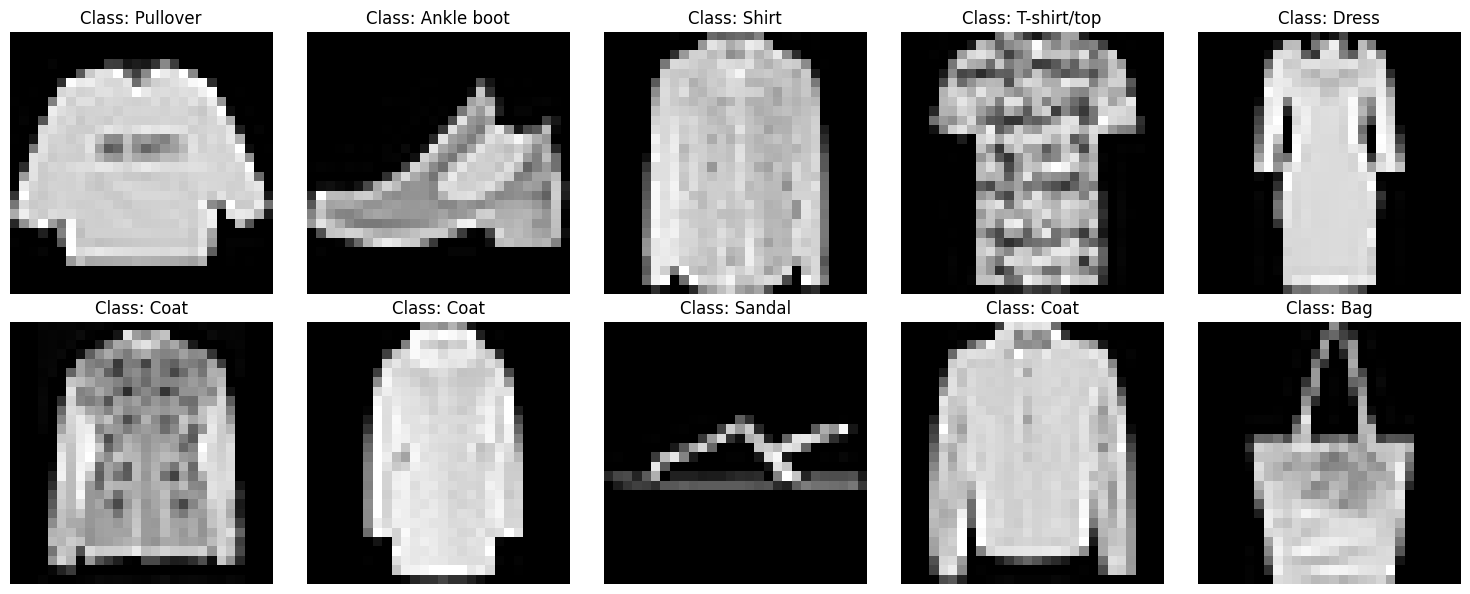

In [ ]:
class_names = [
    'T-shirt/top',  # 0
    'Trouser',      # 1
    'Pullover',     # 2
    'Dress',        # 3
    'Coat',         # 4
    'Sandal',       # 5
    'Shirt',        # 6
    'Sneaker',      # 7
    'Bag',          # 8
    'Ankle boot'    # 9
]

# Hiển thị 10 ảnh đầu
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(f'Class: {class_names[np.argmax(y_train[i])]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
model = Sequential()
model.add(keras.Input(shape=input_shape))

# Conv Block 1
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Conv Block 2
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax'))  # 10 classes

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_fit = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 53s 109ms/step - accuracy: 0.7581 - loss: 0.6708 - val_accuracy: 0.8438 - val_loss: 0.4265
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 107ms/step - accuracy: 0.8450 - loss: 0.4317 - val_accuracy: 0.8733 - val_loss: 0.3495
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 106ms/step - accuracy: 0.8647 - loss: 0.3789 - val_accuracy: 0.8827 - val_loss: 0.3221
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 101ms/step - accuracy: 0.8762 - loss: 0.3465 - val_accuracy: 0.8953 - val_loss: 0.2977
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 47s 110ms/step - accuracy: 0.8858 - loss: 0.3198 - val_accuracy: 0.8950 - val_loss: 0.2899
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 105ms/step - accuracy: 0.8919 - loss: 0.2991 - val_accuracy: 0.9038 - val_loss: 0.2750
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 106ms/step - accuracy: 0.8969 - loss: 0.2832 - val_accuracy: 0.9028 - val_loss: 0.2722
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.9022 - loss: 0

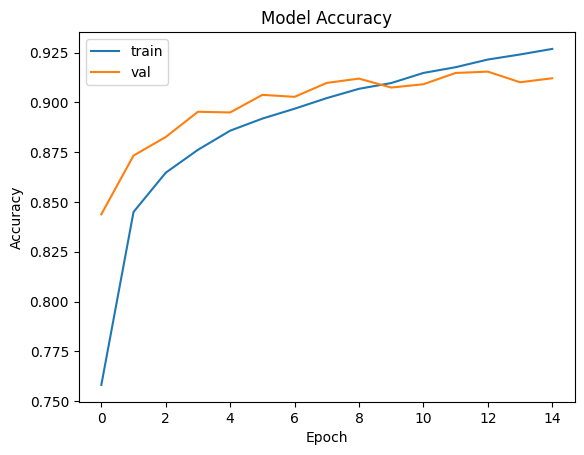

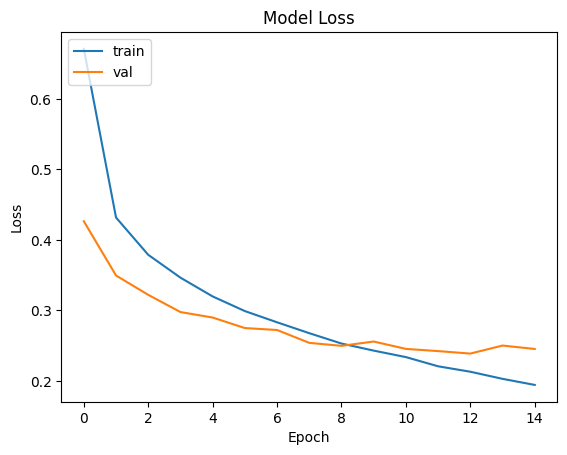

In [ ]:
# Accuracy
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Loss
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [ ]:
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 9ms/step - accuracy: 0.9166 - loss: 0.2330
Test loss:     0.23303812742233276
Test accuracy: 0.9165999889373779


Upload ảnh Fashion (jpg/png, tối đa 20):


Saving ao02.png to ao02.png
[1] ao02.png                       → Bag (57.42%)


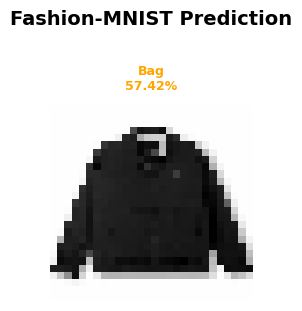

In [ ]:
from google.colab import files
from keras.preprocessing import image
import os

def predict_fashion(img_path):
    img = image.load_img(img_path, target_size=(28, 28),
                         color_mode='grayscale')  # grayscale
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array, verbose=0)[0]
    label_idx = np.argmax(pred)
    confidence = pred[label_idx]

    plt.imshow(img, cmap='gray')
    plt.title(f'Predicted: {class_names[label_idx]}\n{confidence:.2%}')
    plt.axis('off')
    plt.show()

    print(f"→ {class_names[label_idx]} ({confidence:.2%})")

def predict_uploaded_fashion():
    print("Upload ảnh Fashion (jpg/png, tối đa 20):")
    uploaded = files.upload()

    valid = {k: v for k, v in uploaded.items()
             if k.lower().endswith(('.jpg', '.jpeg', '.png'))}

    if not valid:
        print("Không có ảnh hợp lệ.")
        return

    if len(valid) > 20:
        valid = dict(list(valid.items())[:20])

    n = len(valid)
    cols = min(n, 5)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))

    if n == 1:
        axes = np.array([[axes]])
    elif rows == 1:
        axes = axes.reshape(1, -1)
    elif cols == 1:
        axes = axes.reshape(-1, 1)

    for idx, (fname, _) in enumerate(valid.items()):
        r, c = divmod(idx, cols)
        ax = axes[r][c]

        img = image.load_img(fname, target_size=(28, 28),
                             color_mode='grayscale')
        img_array = image.img_to_array(img) / 255.0
        img_array_input = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array_input, verbose=0)[0]
        label_idx = np.argmax(pred)
        confidence = pred[label_idx]
        color = 'green' if confidence >= 0.7 else 'orange'

        ax.imshow(img_array.reshape(28, 28), cmap='gray')
        ax.set_title(
            f'{class_names[label_idx]}\n{confidence:.2%}',
            color=color, fontsize=9, fontweight='bold'
        )
        ax.axis('off')

        print(f"[{idx+1}] {fname:30s} → {class_names[label_idx]} ({confidence:.2%})")

    for idx in range(n, rows * cols):
        r, c = divmod(idx, cols)
        axes[r][c].axis('off')

    plt.suptitle('Fashion-MNIST Prediction', fontsize=14,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    for fname in valid:
        if os.path.exists(fname):
            os.remove(fname)

# Chạy
predict_uploaded_fashion()

In [ ]:
model.save_weights('fashion_cnn.weights.h5')
model.save('fashion_model.keras')